## Month 4 · Feature Selection · Correlation Analysis · SMOTE Verification · Model Training
**Dataset:** `ml_training_dataset_extended.csv`  



## 1. Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve, roc_curve, average_precision_score
)
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import cosine_similarity

print("All imports successful")

All imports successful


## 2. Load Dataset

In [2]:
df = pd.read_csv('ml_training_dataset_extended.csv')
print(f"Shape: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")
print(f"Nulls: {df.isnull().sum().sum()}")
df.head(3)

Shape: (3000, 65)
Label distribution:
label
1    2221
0     779
Name: count, dtype: int64
Nulls: 0


,user_id,item_id,event_type,created_at,destination_category,event_weight,recency_weight,days_ago,interest_sightseeing,interest_culture,...,Nature_dest_score,Beach_dest_score,Adventure_dest_score,Relaxation_dest_score,click_frequency,user_item_affinity,category_diversity,trust_score,user_total_feedback_count,label
0,user_182,dest_38,save_trip,2026-03-01 08:22:35.197000+00:00,Relaxation,3.0,0.2703,26.164052,0.7476,0.4526,...,0.58,0.00,0.35,0.75,0.0000,0.6609,0.421,0.339,0.7110,1
1,user_178,dest_57,trip_click,2026-03-05 21:39:22.078000+00:00,Beach,1.0,0.3394,21.610732,0.7334,0.3966,...,0.40,0.75,0.48,0.70,0.6309,0.4937,0.264,0.412,0.8149,1
2,user_198,dest_71,trip_click,2026-03-27 06:31:43.744000+00:00,Adventure,1.0,0.9880,0.241037,0.7750,0.2854,...,0.00,0.72,0.76,0.48,0.6309,0.5858,0.621,0.775,0.1252,1


## 3. Feature Drops — Confirmed Removals


**Confirmed drops (data analysis + domain knowledge):**

drop the relaxation-related features (fb_rate_relaxation, cat_recency_relaxation, cat_usage_share_relaxation) because relaxation has only 1 destination in the dataset — they add noise, not signal.


In [4]:
META_COLS   = ['user_id','item_id','event_type','created_at',
               'destination_category','recency_weight']

ALL_DROPS = META_COLS + ['fb_rate_relaxation', 'cat_recency_relaxation', 'cat_usage_share_relaxation']

X_raw = df.drop(columns=ALL_DROPS + ['label'])
y     = df['label'].astype(int)

print(f"Columns removed: {len(ALL_DROPS)}")
print(f"Feature matrix shape: {X_raw.shape}")
print(f"\nAll {len(X_raw.columns)} features:")
for i, c in enumerate(X_raw.columns, 1):
    print(f"  {i:2}. {c}")

Columns removed: 9
Feature matrix shape: (3000, 55)

All 55 features:
   1. event_weight
   2. days_ago
   3. interest_sightseeing
   4. interest_culture
   5. interest_history
   6. interest_nature
   7. interest_beach
   8. interest_adventure
   9. interest_relaxation
  10. interest_strength
  11. booking_rate
  12. save_rate
  13. exploration_rate
  14. conversion_rate
  15. travel_pace_preference
  16. category_loyalty_score
  17. user_unique_dests
  18. user_active_days
  19. feedback_positivity_rate
  20. fb_rate_sightseeing
  21. fb_rate_culture
  22. fb_rate_history
  23. fb_rate_nature
  24. fb_rate_beach
  25. fb_rate_adventure
  26. dest_feedback_rate
  27. dest_pos_feedback_count
  28. dest_total_feedback
  29. cat_usage_share_sightseeing
  30. cat_usage_share_culture
  31. cat_usage_share_history
  32. cat_usage_share_nature
  33. cat_usage_share_beach
  34. cat_usage_share_adventure
  35. cat_recency_sightseeing
  36. cat_recency_culture
  37. cat_recency_history
  38. ca

## 4. Feature Correlation Analysis

### How to check correlation between features in Python

Three main methods:
1. **`.corr()`** — pairwise Pearson correlation between all numeric columns  
2. **`.corrwith()`** — correlation of all columns against a single target series  
3. **Seaborn heatmap** — visual representation of the correlation matrix

Use correlation to detect:
- **Redundant pairs** (|corr| > 0.90) → drop the lower-importance one  
- **Label correlation** → which features actually predict the target  
- **Multicollinearity** → features that confuse linear models


In [5]:
# ── Method 1: Pairwise correlation matrix ──────────────────────────────
corr_matrix = X_raw.corr()

# ── Method 2: Correlation of every feature with the label ───────────────
label_corr = X_raw.corrwith(y).sort_values(ascending=False)
print("=== Top 15 features by correlation with label ===")
print(label_corr.head(30).round(4).to_string())
print()
print("=== Bottom 10 (negative / near-zero) ===")
print(label_corr.tail(25).round(4).to_string())

=== Top 15 features by correlation with label ===
event_weight                 0.5042
feedback_positivity_rate     0.2945
fb_rate_nature               0.2283
click_frequency              0.2221
fb_rate_culture              0.2179
fb_rate_beach                0.2109
fb_rate_history              0.2052
fb_rate_sightseeing          0.2034
fb_rate_adventure            0.1515
dest_feedback_rate           0.1127
dest_pos_feedback_count      0.1126
travel_pace_preference       0.1041
save_rate                    0.1035
conversion_rate              0.0822
user_item_affinity           0.0772
weighted_engagement_norm     0.0609
cat_usage_share_history      0.0573
trust_score                  0.0433
user_unique_dests            0.0415
booking_rate                 0.0415
cat_usage_share_adventure    0.0353
booked_users_norm            0.0342
user_active_days             0.0314
dest_total_feedback          0.0251
interest_sightseeing         0.0215
cat_recency_nature           0.0202
cat_usage_shar

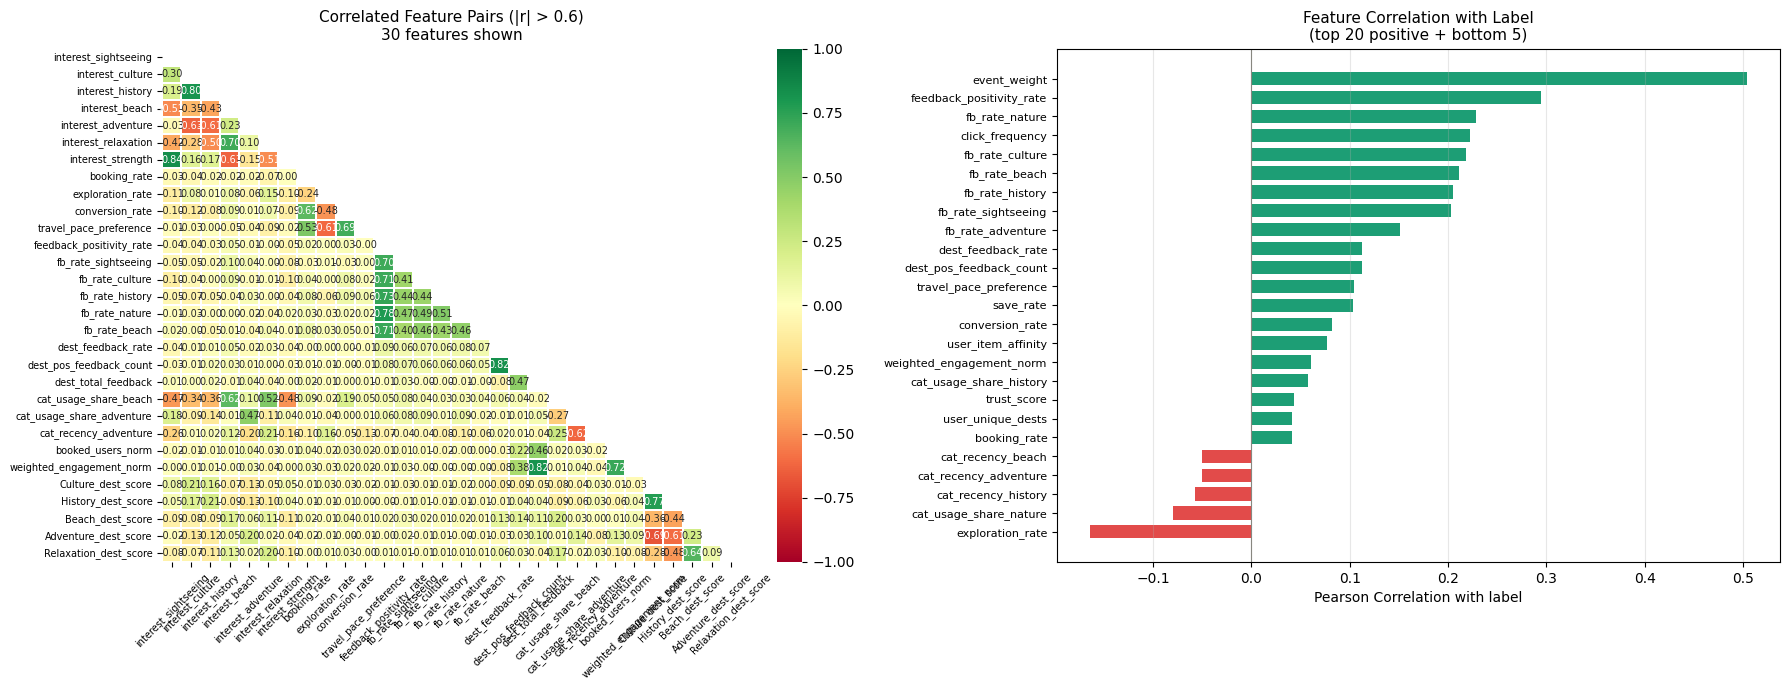

Saved: correlation_analysis.png


In [6]:
# ── Method 3: Heatmap — high-correlation pairs ─────────────────────────
# Show only features with at least one |correlation| > 0.6 with another feature
# to keep the plot readable (full 75x75 is too dense)

high_corr_mask = (corr_matrix.abs() > 0.6) & (corr_matrix.abs() < 1.0)
high_corr_cols = corr_matrix.columns[high_corr_mask.any(axis=0)].tolist()

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Left: High-correlation subset heatmap
subset = corr_matrix.loc[high_corr_cols, high_corr_cols]
mask   = np.triu(np.ones_like(subset, dtype=bool))
sns.heatmap(subset, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, vmin=-1, vmax=1, ax=axes[0],
            annot_kws={'size': 7}, linewidths=0.3)
axes[0].set_title(f'Correlated Feature Pairs (|r| > 0.6)\n{len(high_corr_cols)} features shown',
                  fontsize=11)
axes[0].tick_params(axis='x', rotation=45, labelsize=7)
axes[0].tick_params(axis='y', rotation=0,  labelsize=7)

# Right: Label correlation bar chart (top 20 + bottom 5)
top20 = pd.concat([label_corr.head(20), label_corr.tail(5)])
colors = ['#1D9E75' if v >= 0 else '#E24B4A' for v in top20.values]
axes[1].barh(range(len(top20)), top20.values, color=colors, height=0.7)
axes[1].set_yticks(range(len(top20)))
axes[1].set_yticklabels(top20.index, fontsize=8)
axes[1].invert_yaxis()
axes[1].axvline(0, color='#888780', linewidth=0.8)
axes[1].set_xlabel('Pearson Correlation with label')
axes[1].set_title('Feature Correlation with Label\n(top 20 positive + bottom 5)', fontsize=11)
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: correlation_analysis.png")

In [7]:
# ── Identify exact duplicates and high-corr pairs ──────────────────────
print("=== Exact duplicate pairs (corr == 1.000) ===")
checked = set()
for col in corr_matrix.columns:
    for other in corr_matrix.columns:
        if col != other and (col, other) not in checked and (other, col) not in checked:
            if abs(corr_matrix.loc[col, other]) > 0.9999:
                print(f"  EXACT: {col} <-> {other}  corr={corr_matrix.loc[col,other]:.6f}")
            checked.add((col, other))

print()
print("=== High correlation pairs (0.85 <= |r| < 1.000) ===")
checked2 = set()
for col in corr_matrix.columns:
    for other in corr_matrix.columns:
        if col != other and (col, other) not in checked2 and (other, col) not in checked2:
            r = corr_matrix.loc[col, other]
            if 0.85 <= abs(r) < 0.9999:
                print(f"  HIGH:  {col} <-> {other}  corr={r:.4f}")
            checked2.add((col, other))

=== Exact duplicate pairs (corr == 1.000) ===

=== High correlation pairs (0.85 <= |r| < 1.000) ===


## 5. Feature Importance — Random Forest on 75 Features

In [14]:
X_tr, X_te, y_tr, y_te = train_test_split(
    X_raw, y, test_size=0.2, random_state=42, stratify=y)

rf_imp = RandomForestClassifier(
    n_estimators=300, random_state=42, class_weight='balanced', n_jobs=-1)
rf_imp.fit(X_tr, y_tr)

importances = pd.DataFrame({
    'feature':    X_raw.columns,
    'importance': rf_imp.feature_importances_
}).sort_values('importance', ascending=False).reset_index(drop=True)

importances['group'] = importances['feature'].apply(lambda f:
    'Interaction'       if f in ['click_frequency','user_item_affinity',
                                  'trust_score','user_total_feedback_count'] else
    'Feedback Rating'   if f.startswith('fb_rate_') or f in ['feedback_positivity_rate',
                          'dest_feedback_rate','dest_pos_feedback_count','dest_total_feedback',
                          'aggregate_feedback_rating'] else
    'Dest Item Feature' if f in ['booked_users_norm','weighted_engagement_norm'] else
    'Dest Score'        if f.endswith('dest_score') and not f.startswith('fb_') else
    'User Interest'     if f.startswith('interest_') else
    'Preference Pattern' if f in ['booking_rate','save_rate','exploration_rate','conversion_rate',
                                   'travel_pace_preference','category_loyalty_score',
                                   'user_unique_dests','user_active_days','interest_strength'] else
    'Category Usage'
)

THRESHOLD = 0.005

print(f"AUC on 54 features (pre-selection): {roc_auc_score(y_te, rf_imp.predict_proba(X_te)[:,1]):.4f}")

importances.head(70)

AUC on 54 features (pre-selection): 0.9345


,feature,importance,group
0,event_weight,0.396435,Category Usage
1,feedback_positivity_rate,0.039618,Feedback Rating
2,click_frequency,0.032795,Interaction
3,days_ago,0.028447,Category Usage
4,user_item_affinity,0.027631,Interaction
5,dest_feedback_rate,0.027560,Feedback Rating
6,weighted_engagement_norm,0.020566,Dest Item Feature
7,dest_pos_feedback_count,0.020035,Feedback Rating
8,fb_rate_nature,0.019562,Feedback Rating
9,aggregate_feedback_rating,0.019228,Feedback Rating


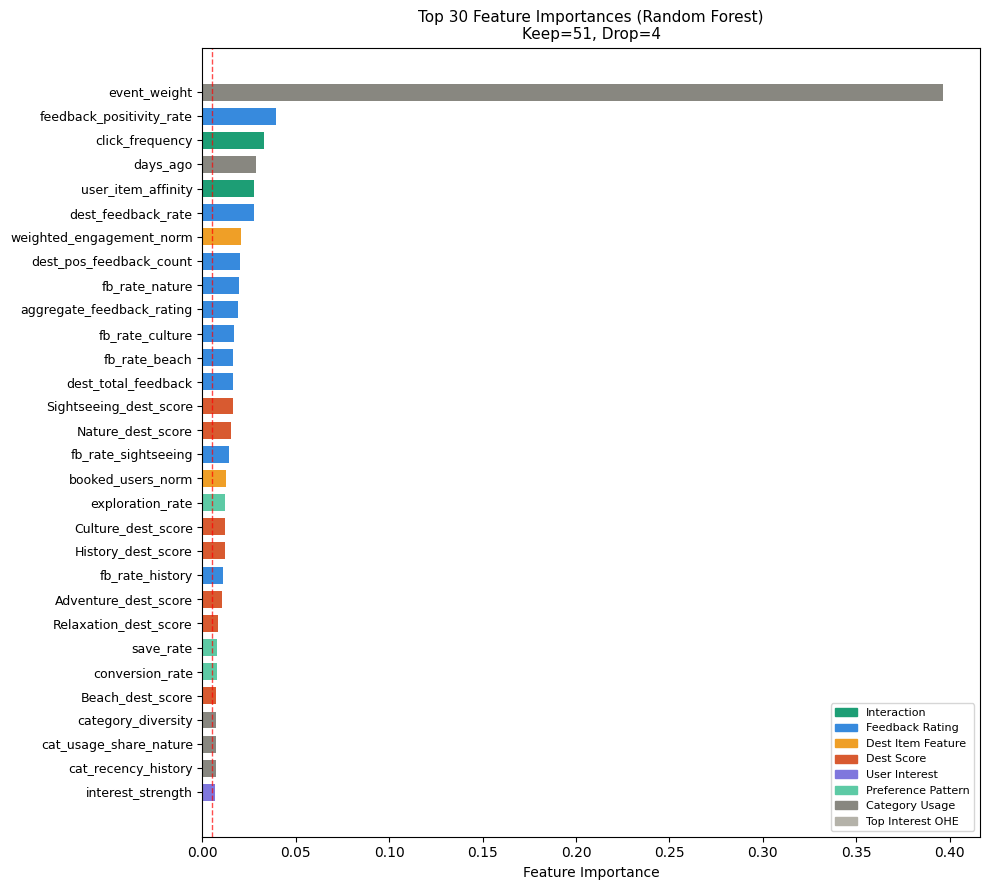

In [15]:
# Feature importance bar chart
COLORS = {
    'Interaction':       '#1D9E75',
    'Feedback Rating':   '#378ADD',
    'Dest Item Feature': '#EF9F27',
    'Dest Score':        '#D85A30',
    'User Interest':     '#7F77DD',
    'Preference Pattern':'#5DCAA5',
    'Category Usage':    '#888780',
    'Top Interest OHE':  '#B4B2A9',
}
top30 = importances.head(30)

fig, ax = plt.subplots(figsize=(10, 9))
bar_colors = [COLORS.get(g, '#888780') for g in top30['group']]
ax.barh(range(len(top30)), top30['importance'], color=bar_colors, height=0.7)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['feature'], fontsize=9)
ax.invert_yaxis()
ax.axvline(THRESHOLD, color='red', linestyle='--', linewidth=1, alpha=0.7,
           label=f'Threshold = {THRESHOLD}')
ax.set_xlabel('Feature Importance')
ax.set_title(f'Top 30 Feature Importances (Random Forest)\nKeep={len(keep_features)}, Drop={len(drop_low)}',
             fontsize=11)
patches = [mpatches.Patch(color=v, label=k) for k, v in COLORS.items()]
ax.legend(handles=patches, loc='lower right', fontsize=8)
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. SMOTE — Custom Implementation (No Duplicates)

### How SMOTE works mathematically

For each minority (label=0) sample **P**:
1. Find its **k nearest minority neighbors**
2. Pick one neighbor **N** at random  
3. Generate a synthetic point: `synthetic = P + gap × (N - P)` where `gap ∈ [0.1, 0.9]`  
4. Check the point has not been seen before (deduplication)

The gap between 0.1 and 0.9 ensures the synthetic point lies **between** P and N — never at the boundary — which avoids copying either original.

**All values stay in [0, 1]** because P and N are both in [0,1] and linear interpolation preserves bounds.


In [17]:
M_COLS   = ['user_id','item_id','event_type','created_at',
               'destination_category']

ALL_DROPS = M_COLS

X_raw = df.drop(columns=ALL_DROPS + ['label'])
y     = df['label'].astype(int)

keep_features = X_raw.columns.tolist()

In [18]:
def smote_no_duplicates(X_minority, n_synthetic, k=5, random_state=42):
    """
    Custom SMOTE using sklearn NearestNeighbors.
    Generates synthetic minority samples by interpolating between
    each minority sample and one of its k nearest minority neighbors.
    A seen-set prevents any synthetic point duplicating an existing point.

    Parameters
    ----------
    X_minority  : np.ndarray (n_minority, n_features) — all minority rows
    n_synthetic : int — number of new synthetic rows to generate
    k           : int — number of nearest neighbors to consider (default 5)
    random_state: int — reproducibility seed

    Returns
    -------
    np.ndarray (n_synthetic, n_features)
    """
    rng = np.random.RandomState(random_state)
    nn  = NearestNeighbors(n_neighbors=k + 1, algorithm='auto')
    nn.fit(X_minority)
    _, indices = nn.kneighbors(X_minority)   # indices[i][0] = self, [1..k] = neighbors

    synthetic = []
    seen      = set(map(tuple, X_minority.round(6)))  # seed with originals
    attempts  = 0
    max_att   = n_synthetic * 30

    while len(synthetic) < n_synthetic and attempts < max_att:
        attempts += 1
        idx      = rng.randint(0, len(X_minority))          # random minority row
        nn_idx   = indices[idx][rng.randint(1, k + 1)]      # random neighbor (skip self)
        gap      = rng.uniform(0.1, 0.9)                    # interpolation factor
        new_pt   = X_minority[idx] + gap * (X_minority[nn_idx] - X_minority[idx])
        new_pt   = np.clip(new_pt, 0.0, 1.0)               # stay in [0,1]
        key      = tuple(new_pt.round(6))
        if key not in seen:
            seen.add(key)
            synthetic.append(new_pt)

    if len(synthetic) < n_synthetic:
        print(f"Warning: only generated {len(synthetic)}/{n_synthetic}. "
              f"Try increasing k or relaxing tolerance.")

    return np.array(synthetic)

print("SMOTE function defined.")

SMOTE function defined.


### 7.1 SMOTE Calculation Trace — Verify Actual Values

This cell shows the exact arithmetic for one synthetic sample so you can verify the values are being computed correctly from the real feature data.

In [ ]:
X_arr = X_raw.values   # convert to numpy
y_arr = y.values

X_minority = X_arr[y_arr == 0]
X_majority = X_arr[y_arr == 1]

# ── Trace one synthetic generation step ────────────────────────────────
TRACE_FEATURES = [
    'feedback_positivity_rate', 'fb_rate_nature', 'click_frequency',
    'user_item_affinity', 'dest_feedback_rate', 'weighted_engagement_norm',
    'aggregate_feedback_rating', 'Sightseeing_score', 'trust_score'
]
trace_idx = [keep_features.index(f) for f in TRACE_FEATURES if f in keep_features]
trace_names = [keep_features[i] for i in trace_idx]

# Use NearestNeighbors to find real neighbors
nn_trace = NearestNeighbors(n_neighbors=6, algorithm='auto').fit(X_minority)
_, nn_indices = nn_trace.kneighbors(X_minority)

# Pick row 0 and its first real neighbor
parent_row   = 0
neighbor_row = nn_indices[parent_row][1]
gap_used     = 0.4    # fixed for demonstration

P = X_minority[parent_row]
N = X_minority[neighbor_row]
S = np.clip(P + gap_used * (N - P), 0, 1)

print("=" * 65)
print("SMOTE CALCULATION TRACE — Formula: S = P + gap × (N - P)")
print(f"Gap used: {gap_used}")
print("=" * 65)
print(f"{'Feature':<35} {'P (parent)':>12} {'N (neighbor)':>13} {'S (synthetic)':>14}")
print("-" * 65)
for name, i in zip(trace_names, trace_idx):
    print(f"{name:<35} {P[i]:>12.6f} {N[i]:>13.6f} {S[i]:>14.6f}")
print("-" * 65)
print()
print("Manual check (feedback_positivity_rate):")
p_val = P[trace_idx[0]]
n_val = N[trace_idx[0]]
s_val = p_val + gap_used * (n_val - p_val)
print(f"  P={p_val:.6f}, N={n_val:.6f}, gap={gap_used}")
print(f"  S = {p_val:.6f} + {gap_used} × ({n_val:.6f} - {p_val:.6f})")
print(f"  S = {p_val:.6f} + {gap_used} × ({n_val-p_val:.6f})")
print(f"  S = {s_val:.6f}  ✓ matches table above")

SMOTE CALCULATION TRACE — Formula: S = P + gap × (N - P)
Gap used: 0.4
Feature                               P (parent)  N (neighbor)  S (synthetic)
-----------------------------------------------------------------
feedback_positivity_rate                0.454500      0.454500       0.454500
fb_rate_nature                          0.500000      0.500000       0.500000
click_frequency                         0.000000      0.630900       0.252360
user_item_affinity                      0.590500      0.615600       0.600540
dest_feedback_rate                      0.516100      0.285700       0.423940
weighted_engagement_norm                0.642400      0.801300       0.705960
aggregate_feedback_rating               0.518100      0.518100       0.518100
trust_score                             0.734000      0.734000       0.734000
-----------------------------------------------------------------

Manual check (feedback_positivity_rate):
  P=0.454500, N=0.454500, gap=0.4
  S = 0.454500 + 0.

### 7.2 Run SMOTE and Verify Balance

In [ ]:
n_majority  = len(X_majority)
n_minority  = len(X_minority)
n_synthetic = n_majority - n_minority

print(f"Before SMOTE:")
print(f"  Majority (label=1): {n_majority:,}")
print(f"  Minority (label=0): {n_minority:,}")
print(f"  Imbalance ratio:    {n_majority/n_minority:.2f}:1")
print(f"  Synthetic needed:   {n_synthetic:,}")

X_synthetic = smote_no_duplicates(X_minority, n_synthetic=n_synthetic, k=5, random_state=42)
y_synthetic = np.zeros(len(X_synthetic), dtype=int)

# Assemble and shuffle balanced dataset
X_balanced = np.vstack([X_majority, X_minority, X_synthetic])
y_balanced = np.concatenate([np.ones(n_majority, int),
                             np.zeros(n_minority, int),
                             np.zeros(len(X_synthetic), int)])
shuf        = np.random.RandomState(42).permutation(len(X_balanced))
X_balanced  = X_balanced[shuf]
y_balanced  = y_balanced[shuf]

print(f"\nAfter SMOTE:")
print(f"  Majority (label=1):   {(y_balanced==1).sum():,}")
print(f"  Minority (label=0):   {(y_balanced==0).sum():,}")
print(f"  Total rows:           {len(X_balanced):,}")
print(f"  Synthetic generated:  {len(X_synthetic):,}")
dup_count = len(set(map(tuple, X_synthetic.round(6))) & set(map(tuple, X_minority.round(6))))
print(f"  Duplicate check:      {dup_count} overlaps with originals  ({'✓ PASS' if dup_count==0 else '✗ FAIL'})")
print(f"  All values in [0,1]:  {((X_balanced >= 0) & (X_balanced <= 1)).all()}  ({'✓ PASS' if ((X_balanced >= 0) & (X_balanced <= 1)).all() else '✗ FAIL'})")

Before SMOTE:
  Majority (label=1): 2,221
  Minority (label=0): 779
  Imbalance ratio:    2.85:1
  Synthetic needed:   1,442

After SMOTE:
  Majority (label=1):   2,221
  Minority (label=0):   2,221
  Total rows:           4,442
  Synthetic generated:  1,442
  Duplicate check:      0 overlaps with originals  (✓ PASS)
  All values in [0,1]:  True  (✓ PASS)


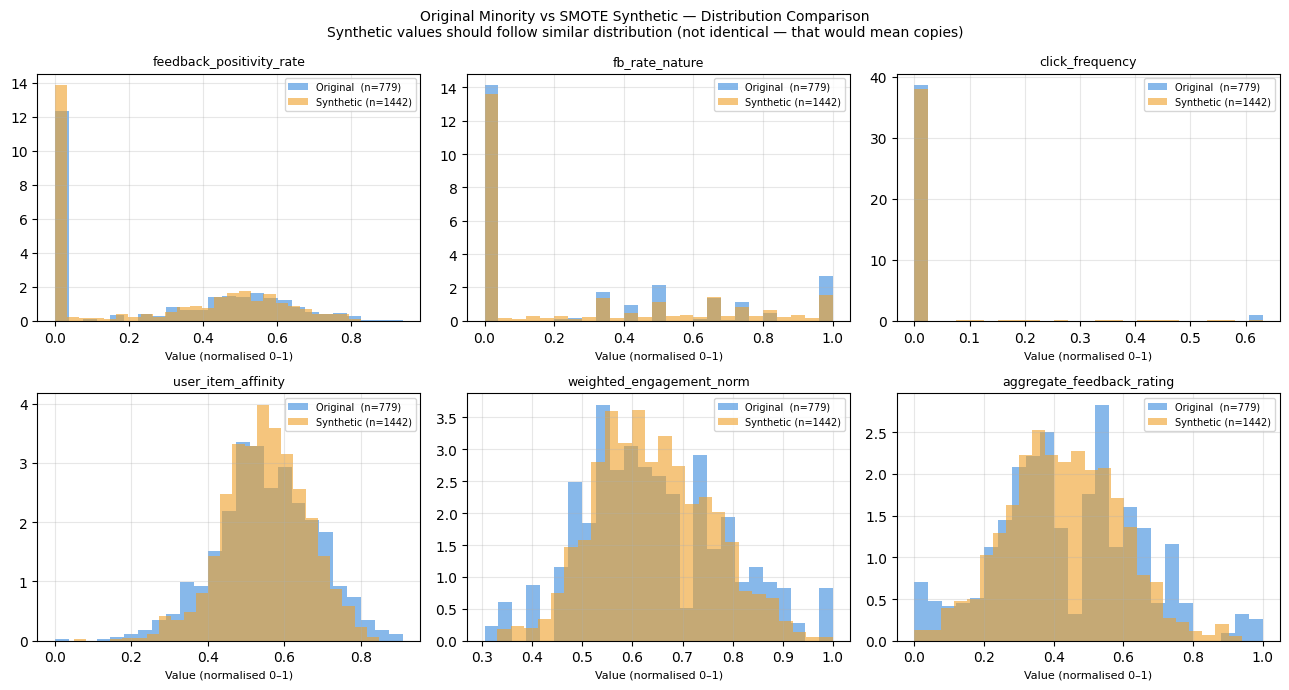

In [ ]:
# ── Distribution comparison: original minority vs synthetic ─────────────
fig, axes = plt.subplots(2, 3, figsize=(13, 7))
check_feats = ['feedback_positivity_rate','fb_rate_nature','click_frequency',
               'user_item_affinity','weighted_engagement_norm','aggregate_feedback_rating']

for ax, feat in zip(axes.flat, check_feats):
    if feat not in keep_features:
        ax.set_visible(False); continue
    fi = keep_features.index(feat)
    orig_vals  = X_minority[:, fi]
    synth_vals = X_synthetic[:, fi]
    ax.hist(orig_vals,  bins=25, alpha=0.6, color='#378ADD', label=f'Original  (n={len(orig_vals)})',  density=True)
    ax.hist(synth_vals, bins=25, alpha=0.6, color='#EF9F27', label=f'Synthetic (n={len(synth_vals)})', density=True)
    ax.set_title(feat, fontsize=9)
    ax.set_xlabel('Value (normalised 0–1)', fontsize=8)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

fig.suptitle('Original Minority vs SMOTE Synthetic — Distribution Comparison\n'
             'Synthetic values should follow similar distribution (not identical — that would mean copies)',
             fontsize=10)
plt.tight_layout()
plt.savefig('smote_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

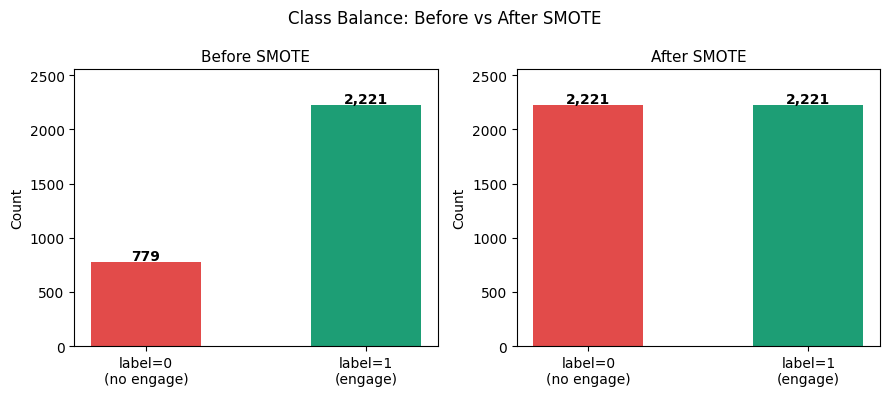

In [ ]:
# ── Class balance plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(9, 4))
for ax, (counts, title) in zip(axes, [
    ([n_minority, n_majority], 'Before SMOTE'),
    ([(y_balanced==0).sum(), (y_balanced==1).sum()], 'After SMOTE')
]):
    ax.bar(['label=0\n(no engage)', 'label=1\n(engage)'],
           counts, color=['#E24B4A','#1D9E75'], width=0.5)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Count')
    for i, v in enumerate(counts):
        ax.text(i, v + 20, f'{v:,}', ha='center', fontweight='bold', fontsize=10)
    ax.set_ylim(0, max(counts) * 1.15)
plt.suptitle('Class Balance: Before vs After SMOTE', fontsize=12)
plt.tight_layout()
plt.savefig('class_balance.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import pandas as pd

# Convert balanced arrays to DataFrame
df_balanced = pd.DataFrame(X_balanced, columns=keep_features)
df_balanced['label'] = y_balanced

# Save to CSV
df_balanced.to_csv("smote_balanced_dataset.csv", index=False)

print("✅ SMOTE balanced dataset saved as 'smote_balanced_dataset.csv'")

✅ SMOTE balanced dataset saved as 'smote_balanced_dataset.csv'
